# Bayesian Optimization for Controller Tuning

This notebook shows how to wrap a TuneControl benchmark task inside a standard
Bayesian optimisation (BO) loop using BoTorch. We keep the example close to the
classic tutorial setup: a single cart-pole gain parameter tuned via BO.


In [7]:
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from botorch.acquisition import LogExpectedImprovement, UpperConfidenceBound
from botorch.acquisition.max_value_entropy_search import qMaxValueEntropy
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.optim import optimize_acqf
from botorch.utils.transforms import unnormalize
from gpytorch.constraints import Interval
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood
from torch.quasirandom import SobolEngine

import tunecontrol as tc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double
SMOKE_TEST = os.environ.get("SMOKE_TEST")


In [8]:
ACQ = "MES"  # options: 'EI', 'UCB', 'UCB_const', 'MES'
DIM = 1
NUM_RESTARTS = 10
RAW_SAMPLES = 512
MAX_ITER = 10

task = tc.make("cartpole/1d/mae/default_noise")
bounds = task.bounds.to(device=device, dtype=dtype)
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)


## Helper functions
We evaluate the task in the unit cube and convert the results to tensors that
BoTorch expects.


In [9]:
def eval_objective(x: torch.Tensor, task: tc.Task) -> torch.Tensor:
    x = x.to(device=device, dtype=dtype)
    x = x.view(-1, DIM)
    theta = unnormalize(x, bounds)
    values = []
    for theta_row in theta:
        value, _ = task.evaluate(theta_row)
        values.append(value.to(dtype=dtype, device=device))
    return torch.stack(values).view(-1)

def get_initial_points(dim, n_points, seed=0):
    sobol = SobolEngine(dimension=dim, scramble=True, seed=seed)
    return sobol.draw(n_points).to(dtype=dtype, device=device)


### Visualise the objective over the parameter range


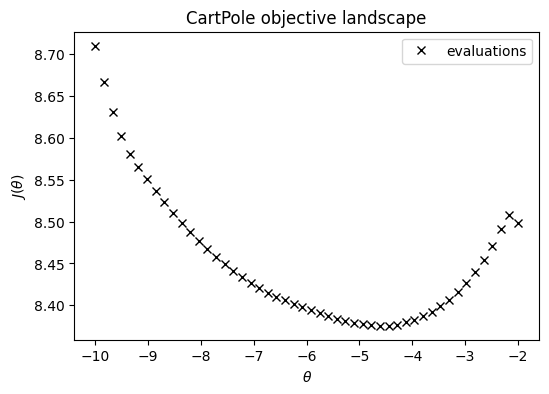

In [10]:
x = torch.linspace(0, 1, 50, device=device, dtype=dtype).unsqueeze(-1)

task_no_noise = tc.make("cartpole/1d/mae/deterministic")

y = eval_objective(x, task_no_noise)
theta_plot = unnormalize(x, bounds).squeeze(-1)

global Y_LB, Y_UB
Y_LB = 8.3
Y_UB = 9.0

plt.figure(figsize=(6, 4))
plt.plot(theta_plot.cpu(), y.cpu(), 'kx', label='evaluations')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$J(\theta)$')
plt.title('CartPole objective landscape')
plt.legend()
plt.show()


### Gaussian process visualisation helper


In [11]:
def plot_gp(model, train_x, train_y, train_stats, title=""):
    model.eval()
    x_test = torch.linspace(0, 1, 100, device=device, dtype=dtype).unsqueeze(-1)
    with torch.no_grad():
        posterior = model.posterior(x_test)
    data_mean = train_stats['mean']
    data_std = train_stats['std']
    if isinstance(data_mean, torch.Tensor):
        data_mean = data_mean.item()
    if isinstance(data_std, torch.Tensor):
        data_std = data_std.item()
    mean_pred = posterior.mean.squeeze(-1).detach() * data_std + data_mean
    var_pred = posterior.variance.squeeze(-1).detach() * (data_std ** 2)
    x_test_plot = unnormalize(x_test, bounds).squeeze(-1).detach().cpu().numpy()
    train_x_plot = unnormalize(train_x, bounds).squeeze(-1).detach().cpu().numpy()
    train_y_plot = train_y.squeeze(-1).detach().cpu().numpy()
    mean_np = mean_pred.cpu().numpy()
    var_np = var_pred.cpu().numpy()
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(train_x_plot, train_y_plot, 'kx', label='Noisy observations')
    ax.plot(x_test_plot, mean_np, 'tab:blue', label='Gaussian process')
    std_np = var_np ** 0.5
    ax.fill_between(x_test_plot, mean_np - std_np, mean_np + std_np, alpha=0.1, color='tab:blue')
    ax.fill_between(x_test_plot, mean_np - 2 * std_np, mean_np + 2 * std_np, alpha=0.1, color='tab:blue')
    best_estimate = x_test_plot[mean_np.argmin()]
    ax.vlines(best_estimate, ymin=Y_LB, ymax=Y_UB, color='r', linestyle='--', label='Pred. optimum')
    ax.vlines(bounds[0, 0].item(), Y_LB, Y_UB, color='k', linestyle='--')
    ax.vlines(bounds[1, 0].item(), Y_LB, Y_UB, color='k', linestyle='--')
    ax.set_ylim([Y_LB, Y_UB])
    ax.set_xlim([bounds[0, 0].item() - 2, bounds[1, 0].item() + 2])
    ax.legend()
    ax.set_title(title)
    ax.set_ylabel(r'Cost $J(\theta)$')
    ax.set_xlabel(r'$\theta$')
    plt.show()
    plt.close()


## Run the BO loop


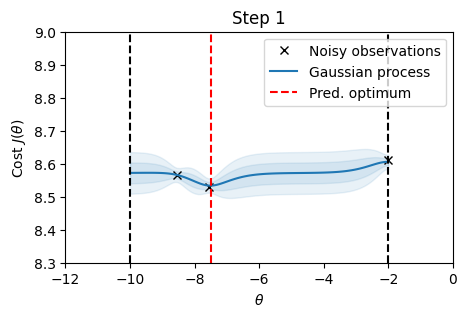

Step  1 | Best value: 8.4563


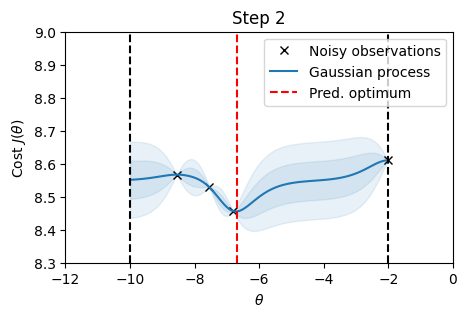

Step  2 | Best value: 8.3994


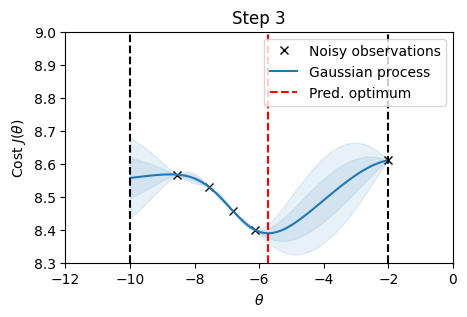

Step  3 | Best value: 8.3994


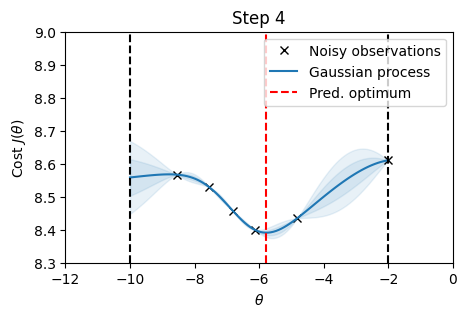

Step  4 | Best value: 8.3994


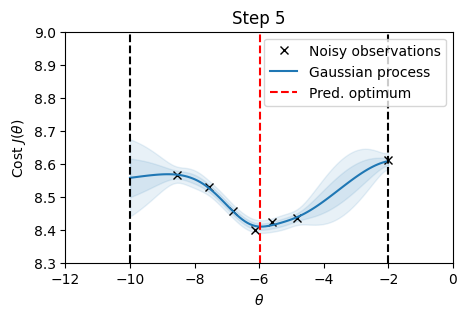

Step  5 | Best value: 8.3994


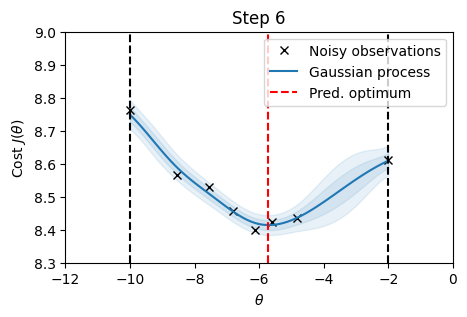

Step  6 | Best value: 8.3994


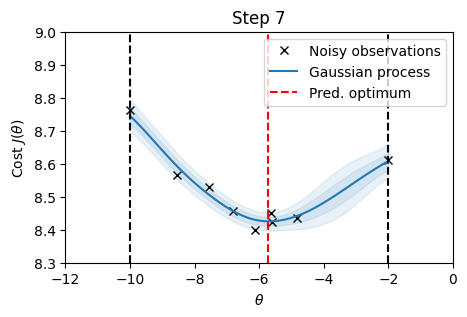

Step  7 | Best value: 8.3994


In [12]:
N_INIT = 3
X = get_initial_points(DIM, N_INIT, seed=seed)
Y = eval_objective(X, task).unsqueeze(-1)

for i in range(1, MAX_ITER - N_INIT + 1):
    std = Y.std() if Y.numel() > 1 else torch.tensor(1.0, dtype=dtype, device=device)
    mean = Y.mean()
    stats = {'mean': mean, 'std': std}
    train_Y = (Y - mean) / std

    likelihood = GaussianLikelihood(noise_constraint=Interval(1e-5, 1e-1))
    covar_module = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=DIM, lengthscale_constraint=Interval(0.005, 4.0)))
    covar_module.base_kernel.lengthscale = math.sqrt(DIM)
    model = SingleTaskGP(X, train_Y, covar_module=covar_module, likelihood=likelihood)
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    if ACQ == 'EI':
        acq_func = LogExpectedImprovement(model, train_Y.max(), maximize=False)
    elif ACQ == 'UCB_const':
        acq_func = UpperConfidenceBound(model, beta=2.0, maximize=False)
    elif ACQ == 'UCB':
        beta = 0.2 * DIM * np.log(2 * (i + N_INIT))
        acq_func = UpperConfidenceBound(model, beta=beta, maximize=False)
    elif ACQ == 'MES':
        candidate_set = torch.rand(1000, DIM, device=device, dtype=dtype)
        acq_func = qMaxValueEntropy(model, candidate_set=candidate_set, maximize=False)
    else:
        raise ValueError('Unknown acquisition function')

    X_next, _ = optimize_acqf(
        acq_func,
        bounds=torch.stack([torch.zeros(DIM, device=device, dtype=dtype), torch.ones(DIM, device=device, dtype=dtype)]),
        q=1,
        num_restarts=NUM_RESTARTS,
        raw_samples=RAW_SAMPLES,
    )

    plot_gp(model, X, Y, stats, title=f'Step {i}')

    Y_next = eval_objective(X_next, task).unsqueeze(-1)
    X = torch.cat((X, X_next), dim=0)
    Y = torch.cat((Y, Y_next), dim=0)
    best_val = torch.min(Y).item()
    print(f'Step {i:2d} | Best value: {best_val:.4f}')
